In [1]:
import tensorflow_probability as tfp
import tensorflow as tf

from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from importlib import reload

In [2]:
import sys
import os
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.layers as layers
from tools_for_VAE import utils, vae_functions, generator, model

W0730 15:59:24.558343 140220180916032 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:65: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
######## Parameters
nb_of_bands = 6
batch_size = 64

input_shape = (64, 64, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 3
filters = [32, 64, 128, 256]#, 512]
kernels = [3,3,3,3]#, 3]

conv_activation = None
dense_activation = None

steps_per_epoch = 32
validation_steps = 8

bands = [4,5,6,7,8,9]

In [4]:
# With generator
images_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/'

list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'training')) if x.endswith('.npy')]
list_of_samples_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation')) if x.endswith('.npy')]
list_of_samples_test = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')]
print(list_of_samples_test)

['/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/test/galaxies_blended_20191024_0_images.npy']


In [5]:
test = np.load('/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

In [6]:
test.shape

(10000, 2, 10, 64, 64)

In [21]:
reload(generator)

<module 'tools_for_VAE.generator' from '../../scripts/tools_for_VAE/tools_for_VAE/generator.py'>

In [22]:
training_generator = generator.BatchGenerator_random_coord_psf(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

[BatchGenerator] total_sample_size =  100000
[BatchGenerator] len(list_of_samples) =  10


In [23]:
test = training_generator.__getitem__(2)

-1.5315035102741286


In [24]:
test[0][0].shape

(64, 64, 64, 6)

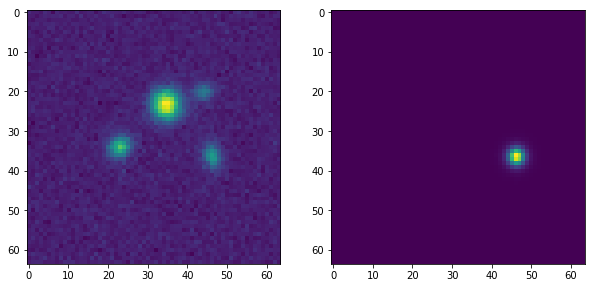

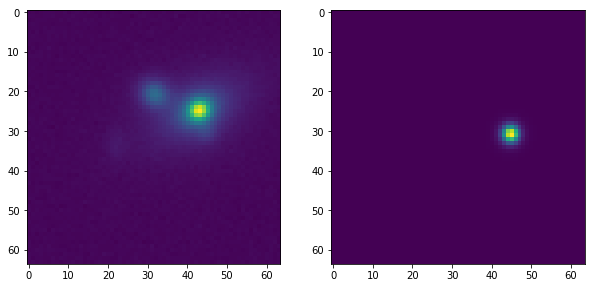

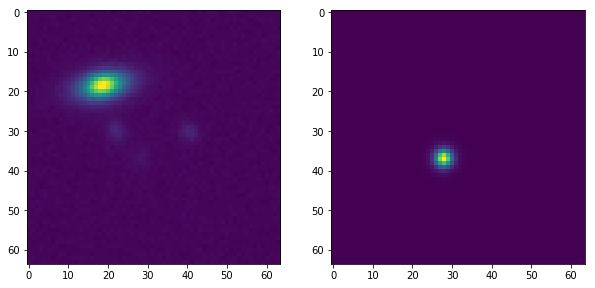

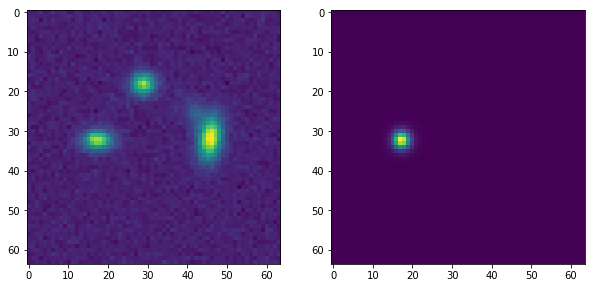

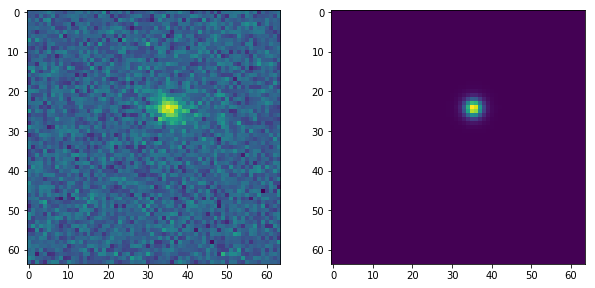

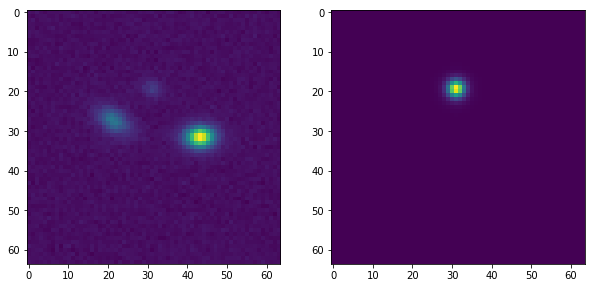

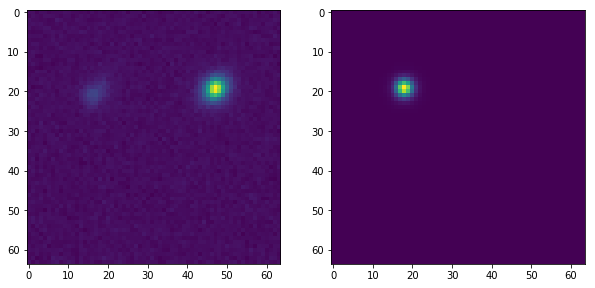

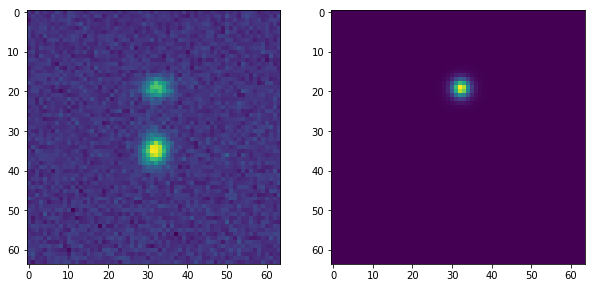

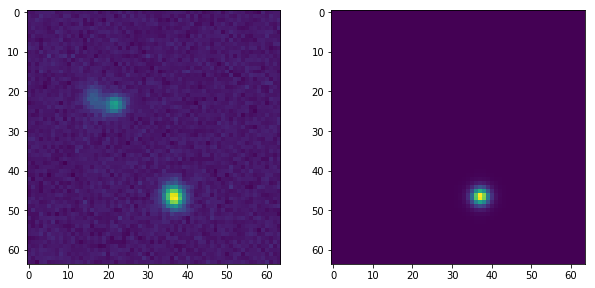

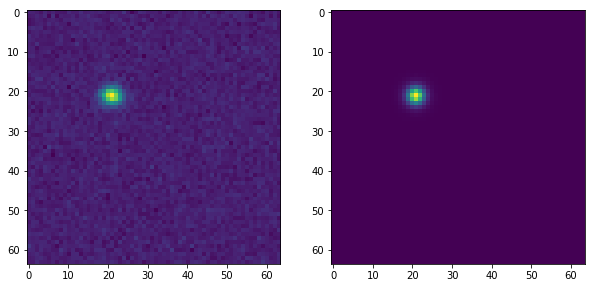

In [25]:
for i in range (10):
    fig, axes = plt.subplots(1,2, figsize =(10,36))
    axes[0].imshow(test[0][0][i,:,:,2])
    axes[1].imshow(test[0][1][i,:,:,2])